**1. 讀取各個需求與答案**

In [6]:
import json

test_gold = []
for i in range(1, 13):
    filename = f"../data/processed/test_gold/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        test_gold.append(json.load(f))
print(test_gold)

[{'user_book_needs': '使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域', 'books': [{'id': '990052691730107976', 'title': '商用微積分 = Calculus for business'}, {'id': '990051193990107976', 'title': '商用微積分'}, {'id': '990060401900107976', 'title': '商用微積分'}, {'id': '990052968700107976', 'title': '商用微積分 = Brief calculus'}, {'id': '990052361310107976', 'title': '商用微積分 = Brief applied calculus'}, {'id': '990060238820107976', 'title': '現代商用微積分 = Modern commercial calculus'}, {'id': '990052069630107976', 'title': '現代商用微積分'}, {'id': '990060053120107976', 'title': '商用微積分 = Calculus for business'}, {'id': '990052567890107976', 'title': '商用微積分 = Adapted From Calculus'}, {'id': '990052684510107976', 'title': '商用微積分(第九版) = Applied calculus for business, economics, and the social and life science'}]}, {'user_book_needs': '使用者的目標是學習有關電腦病毒的基礎知識，包括歷史、類型和防治方法，並且他們的技術水平為初學者', 'books': [{'id': '990051186810107976', 'title': 'Easy to know電腦病毒'}, {'id': '990050146620107976', 'title': '解毒大師 : SCAN 與 PRO-SCAN 使用圖例入

**2. 根據各個需求生成答案 [Baseline]**

In [7]:
import os
import json
import requests
from dotenv import load_dotenv
load_dotenv()

ES_API_URL = os.getenv("ES_API_URL")
ES_API_KEY = os.getenv("ES_API_KEY")
header = {
    "Authorization": f"Apikey {ES_API_KEY}",
    "Content-Type": "application/json"
}
result_baseline = []
for data in test_gold:
    result = {"user_book_needs": data["user_book_needs"], "books": []}
    post_data = {
        "query": {
            "simple_query_string": {
                "query": result["user_book_needs"]
            }
        }
    }
    response = requests.get(f"{ES_API_URL}/books/_search?size=10", headers=header, json=post_data)
    print(response.json())
    for book in response.json()["hits"]["hits"]:
        result["books"].append({
            "id": book["_source"]["id"],
            "title": book["_source"]["title"]
        })
    result_baseline.append(result)
print(json.dumps(result_baseline, indent=2, ensure_ascii=False))

{'took': 4, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 9472, 'relation': 'eq'}, 'max_score': 40.99634, 'hits': [{'_index': 'books', '_id': '990051908290107976', '_score': 40.99634, '_source': {'id': '990051908290107976', 'title': '基礎微積分'}}, {'_index': 'books', '_id': '990051291210107976', '_score': 39.104176, '_source': {'id': '990051291210107976', 'title': '基礎微積分精要'}}, {'_index': 'books', '_id': '990052488760107976', '_score': 37.378967, '_source': {'id': '990052488760107976', 'title': '隨機微積分基礎'}}, {'_index': 'books', '_id': '990050805720107976', '_score': 35.799553, '_source': {'id': '990050805720107976', 'title': '分析基礎課程 : 微積分'}}, {'_index': 'books', '_id': '990052355250107976', '_score': 35.749958, '_source': {'id': '990052355250107976', 'title': '基礎分析學之一 : 單元微積分學'}}, {'_index': 'books', '_id': '990052355210107976', '_score': 33.75782, '_source': {'id': '990052355210107976', 'title': '基礎分析學之二 : 多元微積分學'}}, {'_

**3. 根據各個需求生成答案 [Smart Book Seeker]**

In [3]:
from smart_book_seeker import ConversationManager

result_sbs = []
for data in test_gold:
    result = {"user_book_needs": data["user_book_needs"], "books": []}
    cm = ConversationManager(strategy="iterative_top_k")
    for response in cm.discuss(book_search_needs=result["user_book_needs"]):
        print(f"\033[96m✦\033[0m {response}")
    for book in cm.user_agent.environment.current_books:
        result["books"].append({
            "id": book.id,
            "title": book.title
        })
    result_sbs.append(result)
print(json.dumps(result_sbs, indent=2, ensure_ascii=False))

2025-07-17 15:04:41,693 [INFO] smart_book_seeker.agents.user_needs.handler: User Needs Agent 初始化完成
2025-07-17 15:04:41,700 [INFO] smart_book_seeker.agents.librarian.handler: Librarian Agent 初始化完成
2025-07-17 15:04:43,277 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:04:43,290 [INFO] smart_book_seeker.agents.user.handler: User Agent 初始化完成
2025-07-17 15:04:43,295 [INFO] smart_book_seeker.agents.librarian.handler: Librarian Agent 初始化完成
2025-07-17 15:04:49,323 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:04:49,328 [INFO] smart_book_seeker.agents.user.handler: User Agent 初始化完成
2025-07-17 15:04:51,159 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:04:51,182 [INFO] smart_book_seeker.agents.librarian.tools.handler: [prepare_environment_snapshot]
{
  "initial_book_search_needs": "使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域",
  "

✦ [Librarian Agent] 我根據您的需求，搜尋到以下書籍：
[{"id": "990050296070107976", "title": "商學院微積分", "searched_at_turn": 1}, {"id": "990050825100107976", "title": "商專微積分總複習", "searched_at_turn": 1}, {"id": "990058806790107976", "title": "微積分 /", "searched_at_turn": 1}, {"id": "990051832490107976", "title": "微積分", "searched_at_turn": 1}, {"id": "990061354960107976", "title": "微積分.", "searched_at_turn": 1}, {"id": "990050901110107976", "title": "高等微積分", "searched_at_turn": 1}, {"id": "990052669590107976", "title": "高等微積分 /", "searched_at_turn": 1}, {"id": "990064721150107976", "title": "微積分 = Calculus /", "searched_at_turn": 1}, {"id": "990051193990107976", "title": "商用微積分", "searched_at_turn": 1}, {"id": "990050041210107976", "title": "微積分突破", "searched_at_turn": 1}]


2025-07-17 15:05:08,699 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:05:08,706 [INFO] smart_book_seeker.agents.user.tools.handler: [generate_rationale_for_book_selection]
{
  "rationale": "1. 商學院微積分：標題明確指出是針對商學院設計的微積分教材，符合學習商業微積分基礎概念的需求。\n2. 商專微積分總複習：標題中有商專和微積分，可能涵蓋商業微積分的內容，且是總複習，適合已有基礎的使用者。\n3. 微積分 /：標題較為一般，可能是基礎微積分教材，對於已有基礎者可能較為通用。\n4. 微積分：同上，標題簡單，可能是基礎教材。\n5. 微積分.：同上，標題簡單，可能是基礎教材。\n6. 高等微積分：標題顯示內容較進階，可能超出商業微積分基礎範圍，適合有較深微積分基礎的使用者。\n7. 高等微積分 /：同上，進階內容。\n8. 微積分 = Calculus /：標題為微積分英文對照，可能是較全面的微積分教材，適合有基礎者。\n9. 商用微積分：標題明確指出是商用微積分，符合需求。\n10. 微積分突破：標題暗示有突破性的學習，可能包含較深入或實用的微積分技巧，對已有基礎者有幫助。"
}
2025-07-17 15:05:17,385 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:05:17,454 [INFO] smart_book_seeker.agents.user.tools.handler: [select_books]
{
  "accepted_books": [
    {
      "id": "990050296070107976",
      "title": "商學院微積分",
      "searched_at_turn": 1,
      "reason_for_acceptance":

✦ [User Agent] 我已根據我的需求，對你提供的書籍進行篩選，篩選結果如下：
{"selection_at_turn": 1, "candidate_books": [{"book": {"id": "990050296070107976", "title": "商學院微積分", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "明確針對商學院設計，符合學習商業微積分基礎概念的需求。"}, {"book": {"id": "990050825100107976", "title": "商專微積分總複習", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "標題中包含商專和微積分，可能涵蓋商業微積分內容，且適合已有基礎者。"}, {"book": {"id": "990051193990107976", "title": "商用微積分", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "標題明確指出是商用微積分，符合使用者需求。"}, {"book": {"id": "990050041210107976", "title": "微積分突破", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "可能包含較深入或實用的微積分技巧，對已有基礎者有幫助。"}, {"book": {"id": "990058806790107976", "title": "微積分 /", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "基礎微積分教材，適合已有基礎者作為補充。"}, {"book": {"id": "990051832490107976", "title": "微積分", "searched_at_turn": 1}, "selection_resul

2025-07-17 15:05:20,275 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:05:20,280 [INFO] smart_book_seeker.agents.librarian.tools.handler: [infer_book_search_needs]
{
  "book_search_needs": "學習商業微積分的基礎概念，適合已具備微積分基礎知識的讀者，書籍內容不限定特定應用領域，著重於商業微積分的理論與實務基礎。已找到並接受了10本相關書籍。"
}
2025-07-17 15:05:23,546 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:05:23,559 [INFO] smart_book_seeker.agents.librarian.tools.handler: [generate_rationale]
{
  "rationale": "使用者已根據需求篩選並接受了10本符合學習商業微積分基礎概念的書籍，且這些書籍涵蓋了使用者的需求範圍。由於已達成10本符合需求的書籍數量，符合結束條件，因此下一步應詢問使用者是否結束本次會話。"
}
2025-07-17 15:05:25,292 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:05:25,422 [INFO] smart_book_seeker.agents.librarian.tools.handler: [ask_end_of_session]
{
  "question": "我已經幫您找到並整理了10本符合您學習商業微積分基礎概念需求的書籍。您是否需要結束本次會話，或者還有其他尚未嘗試的書籍搜尋方向想提供？"
}
2025-07-17 15:05:25,424 [INFO] smart_book_see

...

✦ [User Agent] 我已根據我的需求，對你提供的書籍進行篩選，篩選結果如下：
{"selection_at_turn": 3, "candidate_books": [{"book": {"id": "990053028870107976", "title": "FLASH CS4互動網頁設計", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "明確CS4版本，涵蓋互動網頁設計，與需求高度相關。"}, {"book": {"id": "990053160700107976", "title": "Flash CS4 動畫與遊戲製作必修技", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "明確CS4版本，涵蓋動畫與遊戲製作，與需求高度相關。"}, {"book": {"id": "990053158630107976", "title": "Flash CS4動畫設計應用集", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "明確CS4版本，專注動畫設計，相關性高。"}, {"book": {"id": "990052680140107976", "title": "Flash CS4創意動畫設計Level UP", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "明確CS4版本，專注創意動畫設計，相關性高。"}, {"book": {"id": "990053172800107976", "title": "動畫設計王 : 編製與設計一流專業的Flash網頁動畫", "searched_at_turn": 1}, "selection_result": "accepted", "selection_reason": "專注Flash網頁動畫設計，相關性較高。"}, {"book": {"id": "990052759120107976",

2025-07-17 15:20:25,202 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:20:25,265 [INFO] smart_book_seeker.agents.librarian.tools.handler: [infer_book_search_needs]
{
  "book_search_needs": "目前已找到10本符合Flash CS4在網頁設計與動畫製作需求的書籍，包含明確CS4版本及相關性高的書籍，涵蓋動畫設計、互動網頁設計、遊戲製作及ActionScript 3.0。已達成10本目標，無需繼續搜尋。"
}
2025-07-17 15:20:28,869 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:20:28,870 [INFO] smart_book_seeker.agents.librarian.tools.handler: [generate_rationale]
{
  "rationale": "使用者已接受10本符合Flash CS4在網頁設計與動畫製作需求的書籍，已達成目標數量。這些書籍涵蓋了操作技巧、動畫設計、互動網頁設計、遊戲製作及ActionScript 3.0，符合使用者需求。下一步應詢問使用者是否結束本次會話。"
}
2025-07-17 15:20:33,581 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:20:33,583 [INFO] smart_book_seeker.agents.librarian.tools.handler: [ask_end_of_session]
{
  "question": "我們已找到10本符合您需求的Flash CS4在網頁設計與動畫製作方面的書籍，這些書籍涵蓋操作技巧、動畫設計、互動網頁設計、遊戲製作

✦ [Librarian Agent] 我們已找到10本符合您需求的Flash CS4在網頁設計與動畫製作方面的書籍，這些書籍涵蓋操作技巧、動畫設計、互動網頁設計、遊戲製作及ActionScript 3.0。請問您是否需要結束本次會話，或是有其他書籍搜尋需求？


2025-07-17 15:20:37,776 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:20:37,780 [INFO] smart_book_seeker.agents.user.tools.handler: [generate_rationale_for_termination_request_decision]
{
  "rationale": "目前已找到10本符合使用者需求的Flash CS4在網頁設計與動畫製作方面的書籍，這些書籍涵蓋操作技巧、動畫設計、互動網頁設計、遊戲製作及ActionScript 3.0，已充分滿足使用者的搜尋需求。圖書館員已進行了多次搜尋，並且提供了多樣且相關的書籍選擇。基於此，接受終止對話請求是合理的，因為使用者已獲得足夠且符合需求的書籍清單，無需繼續搜尋。"
}
2025-07-17 15:20:45,080 [INFO] httpx: HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2025-07-17 15:20:45,088 [INFO] smart_book_seeker.agents.user.tools.handler: [accept_termination_request]
{
  "reason_for_acceptance": "目前已找到10本符合使用者需求的Flash CS4在網頁設計與動畫製作方面的書籍，這些書籍涵蓋操作技巧、動畫設計、互動網頁設計、遊戲製作及ActionScript 3.0，已充分滿足使用者的搜尋需求。圖書館員已進行了多次搜尋，並且提供了多樣且相關的書籍選擇。基於此，接受終止對話請求是合理的，因為使用者已獲得足夠且符合需求的書籍清單，無需繼續搜尋。"
}
2025-07-17 15:20:45,089 [INFO] smart_book_seeker.conversation_manager: [User Agent] 持有書籍清單：
[
  {
    "id": "990053028870107976",
    "titl

✦ [User Agent] 目前已找到10本符合使用者需求的Flash CS4在網頁設計與動畫製作方面的書籍，這些書籍涵蓋操作技巧、動畫設計、互動網頁設計、遊戲製作及ActionScript 3.0，已充分滿足使用者的搜尋需求。圖書館員已進行了多次搜尋，並且提供了多樣且相關的書籍選擇。基於此，接受終止對話請求是合理的，因為使用者已獲得足夠且符合需求的書籍清單，無需繼續搜尋。
[
  {
    "user_book_needs": "使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域",
    "books": [
      {
        "id": "990050296070107976",
        "title": "商學院微積分"
      },
      {
        "id": "990050825100107976",
        "title": "商專微積分總複習"
      },
      {
        "id": "990051193990107976",
        "title": "商用微積分"
      },
      {
        "id": "990050041210107976",
        "title": "微積分突破"
      },
      {
        "id": "990058806790107976",
        "title": "微積分 /"
      },
      {
        "id": "990051832490107976",
        "title": "微積分"
      },
      {
        "id": "990061354960107976",
        "title": "微積分."
      },
      {
        "id": "990064721150107976",
        "title": "微積分 = Calculus /"
      },
      {
        "id": "990050901110107976",
        "title": "高等微積分"
      },


**4. 計算成績**

In [4]:
score_baseline = []
score_sbs = []
for i, data in enumerate(test_gold):
    data["baseline_books"] = result_baseline[i]["books"]
    data["sbs_books"] = result_sbs[i]["books"]
    score = {"baseline": 0, "sbs": 0}
    for book in data["baseline_books"]:
        for ans_book in data["books"]:
            if book["id"] == ans_book["id"]:
                score["baseline"] += 1
    score["baseline"] *= 10
    for book in data["sbs_books"]:
        for ans_book in data["books"]:
            if book["id"] == ans_book["id"]:
                score["sbs"] += 1
    score["sbs"] *= 10
    score_baseline.append(score["baseline"])
    score_sbs.append(score["sbs"])
    print(f"[{data["user_book_needs"]}] Baseline: {score["baseline"]:.2f}, SBS: {score["sbs"]:.2f}")

[使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域] Baseline: 0.00, SBS: 10.00
[使用者的目標是學習有關電腦病毒的基礎知識，包括歷史、類型和防治方法，並且他們的技術水平為初學者] Baseline: 30.00, SBS: 90.00
[使用者的目標是尋找有關量子物理相關的基礎知識，偏好通俗易懂的介紹] Baseline: 0.00, SBS: 30.00
[使用者的目標是尋找有關電子學的基本知識書籍，專注於基本概念和原理] Baseline: 20.00, SBS: 40.00
[使用者的目標是尋找簡單易懂的書籍，以學習有關不同自然生態或是動物生態的基礎知識] Baseline: 20.00, SBS: 20.00
[使用者的目標是尋找有關使用威力導演11版本以上的工具來做剪輯] Baseline: 40.00, SBS: 70.00
[使用者的目標是尋找有關介紹科學家費曼生平的故事] Baseline: 40.00, SBS: 50.00
[使用者的目標是尋找有關太陽能電池的原理、技術等等知識] Baseline: 60.00, SBS: 50.00
[使用者的目標是尋找有關昆蟲的圖片或是各方面的知識] Baseline: 50.00, SBS: 100.00
[使用者的目標是尋找有關怎麼使用TensorFlow來學習有關深度學習的知識] Baseline: 40.00, SBS: 80.00
[使用者的目標是尋找有關怎麼使用Flash CS3來進行動畫製作] Baseline: 30.00, SBS: 50.00
[使用者的目標是尋找有關怎麼使用Flash CS4來進行網頁設計和動畫製作] Baseline: 40.00, SBS: 40.00


**5. 畫圖**

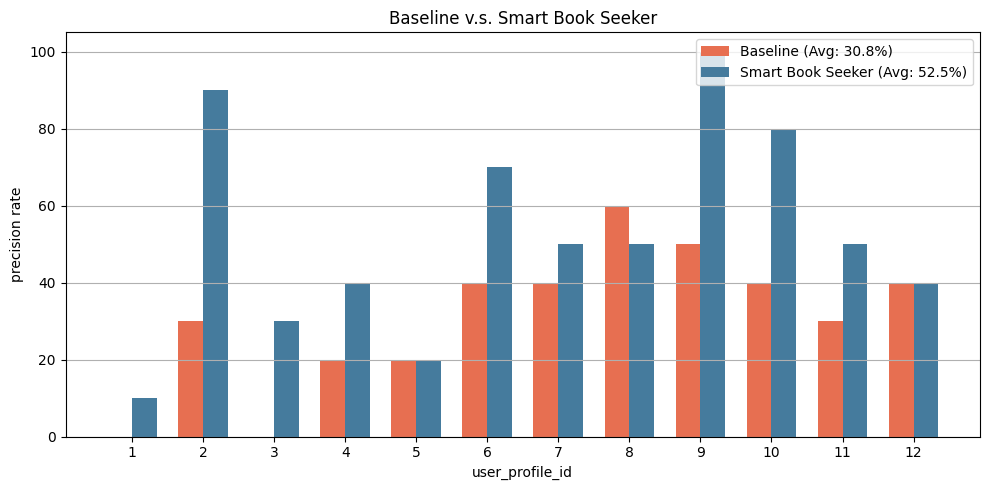

In [5]:
import matplotlib.pyplot as plt

# 資料
base = score_baseline
my =   score_sbs
x = list(range(1, len(base) + 1))

# 計算平均值
base_mean = sum(base) / len(base)
my_mean = sum(my) / len(my)

# 繪圖（改為長條圖）
plt.figure(figsize=(10, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in x], base, width=bar_width, label=f'Baseline (Avg: {base_mean:.1f}%)', color='#E76F51')
plt.bar([i + bar_width/2 for i in x], my, width=bar_width, label=f'Smart Book Seeker (Avg: {my_mean:.1f}%)', color='#457B9D')

plt.xlabel('user_profile_id')
plt.ylabel('precision rate')
plt.title('Baseline v.s. Smart Book Seeker')

plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.xticks(x)

plt.show()